### Here is a link to a helpful video by Bin Wen Brunton explaining concepts in electrical methods in neuroscience
##### If you are not familiar with ephys, this is a must watch
##### https://www.youtube.com/watch?v=LJkr-bJ1-dw&t=1037s

In [1]:
# import all dependencies

import warnings
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import matplotlib.pyplot as plt
    
from pynwb import NWBHDF5IO

## First, load an nwb file and look to see what's inside

In [2]:
from nwb_config import NWB_PATH

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="Ignoring cached namespace")
    io = NWBHDF5IO(NWB_PATH, "r", load_namespaces=True)
    nwb = io.read()

print(nwb)

root pynwb.file.NWBFile at 0x1719952994128
Fields:
  acquisition: {
    raw_running_wheel_rotation <class 'pynwb.base.TimeSeries'>,
    running_wheel_signal_voltage <class 'pynwb.base.TimeSeries'>,
    running_wheel_supply_voltage <class 'pynwb.base.TimeSeries'>
  }
  devices: {
    Device <class 'pynwb.device.Device'>,
    ProbeA <class 'pynwb.device.Device'>,
    ProbeB <class 'pynwb.device.Device'>,
    ProbeC <class 'pynwb.device.Device'>,
    ProbeE <class 'pynwb.device.Device'>
  }
  electrode_groups: {
    ProbeA <class 'pynwb.ecephys.ElectrodeGroup'>,
    ProbeB <class 'pynwb.ecephys.ElectrodeGroup'>,
    ProbeC <class 'pynwb.ecephys.ElectrodeGroup'>,
    ProbeE <class 'pynwb.ecephys.ElectrodeGroup'>
  }
  electrodes: electrodes <class 'hdmf.common.table.DynamicTable'>
  file_create_date: [datetime.datetime(2025, 9, 22, 21, 38, 43, 68254, tzinfo=tzutc())]
  identifier: a5c81890-1b04-4c80-903a-dc9f5137970c
  institution: Allen Institute for Neural Dynamics
  intervals: {
    dri

In [3]:
# not all of this will be necessary, but it's good to see what is in the nwb file

print("\n--- acquisition ---")
print(list(nwb.acquisition.keys()))

print("\n--- devices ---")
print(list(nwb.devices.keys()))

print("\n--- electrode_groups ---")
print(list(nwb.electrode_groups.keys()))

print("\n--- intervals ---")
print(list(nwb.intervals.keys()))

print("\n--- processing ---")
print(list(nwb.processing.keys()))



--- acquisition ---
['raw_running_wheel_rotation', 'running_wheel_signal_voltage', 'running_wheel_supply_voltage']

--- devices ---
['Device', 'ProbeA', 'ProbeB', 'ProbeC', 'ProbeE']

--- electrode_groups ---
['ProbeA', 'ProbeB', 'ProbeC', 'ProbeE']

--- intervals ---
['drifting_gratings_field_block_presentations', 'flash_field_block_presentations', 'receptive_field_block_presentations', 'spontaneous_presentations']

--- processing ---
['ecephys', 'eye_tracking', 'running', 'stimulus']


In [4]:
print("\n--- units columns ---")
print(nwb.units.colnames)

print("\n--- electrodes columns ---")
print(nwb.electrodes.colnames)


--- units columns ---
('spike_times', 'electrodes', 'waveform_mean', 'waveform_sd', 'unit_name', 'drift_ptp', 'decoder_label', 'nn_hit_rate', 'snr', 'depth', 'repolarization_slope', 'firing_rate', 'rp_contamination', 'd_prime', 'amplitude_cv_median', 'amplitude_cutoff', 'shank', 'l_ratio', 'drift_mad', 'nn_miss_rate', 'num_negative_peaks', 'amplitude', 'sliding_rp_violation', 'estimated_z', 'default_qc', 'original_cluster_id', 'drift_std', 'presence_ratio', 'peak_to_valley', 'extremum_channel_index', 'num_spikes', 'velocity_above', 'decoder_probability', 'recovery_slope', 'peak_trough_ratio', 'firing_range', 'isolation_distance', 'amplitude_median', 'half_width', 'isi_violations_ratio', 'silhouette', 'sync_spike_8', 'exp_decay', 'ks_unit_id', 'spread', 'amplitude_cv_range', 'estimated_y', 'estimated_x', 'velocity_below', 'device_name', 'isi_violations_count', 'rp_violations', 'sync_spike_4', 'num_positive_peaks', 'sync_spike_2')

--- electrodes columns ---
('location', 'group', 'group

## Next, we can inspect the stimulus tables

### Drifting gratings stimulus table

In [5]:
# first, select the stimulus block and retrive it from intervals using its key
stimulus_block = 'drifting_gratings_field_block_presentations'
dg_stim_table = nwb.intervals[stimulus_block].to_dataframe()

# we can print the first few rows of the stimulus table to see what conditions it contains
print(dg_stim_table.head())

     start_time    stop_time                      stim_name    stim_type  \
id                                                                         
0   1268.840779  1269.841631  drifting_gratings_field_block  GratingStim   
1   1271.092670  1272.093511  drifting_gratings_field_block  GratingStim   
2   1273.344560  1274.345400  drifting_gratings_field_block  GratingStim   
3   1275.596451  1276.597290  drifting_gratings_field_block  GratingStim   
4   1277.848331  1278.849169  drifting_gratings_field_block  GratingStim   

   stim_block temporal_frequency spatial_frequency orientation contrast  \
id                                                                        
0         1.0                1.0              0.04         0.0      0.8   
1         1.0                1.0              0.02        90.0      0.8   
2         1.0                8.0              0.02        45.0      0.8   
3         1.0                1.0              0.08        45.0      0.8   
4         1.0    

In [6]:
# select relevant conditions for the stimulus
dg_condition_params = ['orientation', 'temporal_frequency', 'spatial_frequency', 'contrast']

# we can clean up the table by dropping rows with missing values in the condition parameters and keep only relevant columns 
# we shouldn't have any rows with missing values, but we can do this just in case
dg_stim_clean = dg_stim_table[dg_condition_params + ['start_time', 'stop_time']].dropna(
    subset=dg_condition_params
).copy()

print(dg_stim_clean.head())

print()

# make sure condition parameters are numeric values
for param in dg_condition_params:
    dg_stim_clean[param] = pd.to_numeric(dg_stim_clean[param], errors='coerce')

# assign a unique stimulus condition ID to each unique combination of condition parameters
dg_stim_clean['stimulus_condition_id'] = dg_stim_clean.groupby(dg_condition_params).ngroup()

# inspect the number of unique conditions for each parameter and the total number of unique stimulus conditions
print("Number of spatial conditions:", dg_stim_clean['spatial_frequency'].nunique())
print("Number of temporal conditions:", dg_stim_clean['temporal_frequency'].nunique())
print("Number of orientation conditions:", dg_stim_clean['orientation'].nunique())
print("Number of unique stimulus conditions:", dg_stim_clean['stimulus_condition_id'].nunique())

print()

# we can calculate the number of unique stimulus conditions by multiplying the number of unique values for each condition parameter
print("Double check number of unique stimulus conditions:", dg_stim_clean['spatial_frequency'].nunique()*dg_stim_clean['temporal_frequency'].nunique()*dg_stim_clean['orientation'].nunique()*dg_stim_clean['contrast'].nunique())

# we can also check the total number of stimuli in the table 
# this implies that each stimulus is presented (total stimuli / unique stimulus conditions) times
print("Total stimuli:", len(dg_stim_clean))
print()

   orientation temporal_frequency spatial_frequency contrast   start_time  \
id                                                                          
0          0.0                1.0              0.04      0.8  1268.840779   
1         90.0                1.0              0.02      0.8  1271.092670   
2         45.0                8.0              0.02      0.8  1273.344560   
3         45.0                1.0              0.08      0.8  1275.596451   
4         45.0                8.0              0.02      0.8  1277.848331   

      stop_time  
id               
0   1269.841631  
1   1272.093511  
2   1274.345400  
3   1276.597290  
4   1278.849169  

Number of spatial conditions: 5
Number of temporal conditions: 5
Number of orientation conditions: 4
Number of unique stimulus conditions: 100

Double check number of unique stimulus conditions: 100
Total stimuli: 1500



### Receptive field stimulus table

In [7]:
# first, select the stimulus block and retrive it from intervals using its key
stimulus_block = 'receptive_field_block_presentations'
rf_stim_table = nwb.intervals[stimulus_block].to_dataframe()

# we can print the first few rows of the stimulus table to see what conditions it contains
print(rf_stim_table.head())

    start_time  stop_time              stim_name    stim_type stim_block  \
id                                                                         
0    42.763471  43.013681  receptive_field_block  GratingStim        0.0   
1    43.013681  43.263890  receptive_field_block  GratingStim        0.0   
2    43.263890  43.514100  receptive_field_block  GratingStim        0.0   
3    43.514100  43.764309  receptive_field_block  GratingStim        0.0   
4    43.764309  44.014517  receptive_field_block  GratingStim        0.0   

   temporal_frequency spatial_frequency orientation contrast x_position  \
id                                                                        
0                 4.0              0.08        90.0      0.8       40.0   
1                 4.0              0.08         0.0      0.8       40.0   
2                 4.0              0.08         0.0      0.8      -40.0   
3                 4.0              0.08        45.0      0.8       40.0   
4                

In [8]:
# select relevant conditions for the stimulus
rf_condition_params = ['orientation', 'temporal_frequency', 'spatial_frequency', 'contrast', 'x_position', 'y_position']

# we can clean up the table by dropping rows with missing values in the condition parameters and keep only relevant columns 
# we shouldn't have any rows with missing values, but we can do this just in case
rf_stim_clean = rf_stim_table[rf_condition_params + ['start_time', 'stop_time']].dropna(
    subset=rf_condition_params
).copy()

print(rf_stim_clean.head())

print()

# make sure condition parameters are numeric values
for param in rf_condition_params:
    rf_stim_clean[param] = pd.to_numeric(rf_stim_clean[param], errors='coerce')

# assign a unique stimulus condition ID to each unique combination of condition parameters
rf_stim_clean['stimulus_condition_id'] = rf_stim_clean.groupby(rf_condition_params).ngroup()

# inspect the number of unique conditions for each parameter and the total number of unique stimulus conditions
print("Number of spatial conditions:", rf_stim_clean['spatial_frequency'].nunique())
print("Number of temporal conditions:", rf_stim_clean['temporal_frequency'].nunique())
print("Number of orientation conditions:", rf_stim_clean['orientation'].nunique()) 

# because this stimulus set is to map the receptive field, we also have unique x and y positions for the stimulus
print("Number of unique x_positions:", rf_stim_clean['x_position'].nunique())
print("Number of unique y_positions:", rf_stim_clean['y_position'].nunique())

# we can calculate the number of unique stimulus conditions by multiplying the number of unique values for each condition parameter
print("Number of unique stimulus conditions:", rf_stim_clean['stimulus_condition_id'].nunique())

print()

# we can also check the total number of stimuli in the table 
# this implies that each stimulus is presented (total stimuli / unique stimulus conditions) times
print("Double check number of unique stimulus conditions:", rf_stim_clean['spatial_frequency'].nunique()*rf_stim_clean['temporal_frequency'].nunique()*rf_stim_clean['orientation'].nunique()*rf_stim_clean['contrast'].nunique()*rf_stim_clean['x_position'].nunique()*rf_stim_clean['y_position'].nunique())
print("Total stimuli:", len(rf_stim_clean))
print()


   orientation temporal_frequency spatial_frequency contrast x_position  \
id                                                                        
0         90.0                4.0              0.08      0.8       40.0   
1          0.0                4.0              0.08      0.8       40.0   
2          0.0                4.0              0.08      0.8      -40.0   
3         45.0                4.0              0.08      0.8       40.0   
4         45.0                4.0              0.08      0.8      -10.0   

   y_position  start_time  stop_time  
id                                    
0       -40.0   42.763471  43.013681  
1       -40.0   43.013681  43.263890  
2       -40.0   43.263890  43.514100  
3        30.0   43.514100  43.764309  
4       -10.0   43.764309  44.014517  

Number of spatial conditions: 1
Number of temporal conditions: 1
Number of orientation conditions: 3
Number of unique x_positions: 9
Number of unique y_positions: 9
Number of unique stimulus condition

## We can also obtain individual unit spikes from the nwb files

In [9]:
# get all of the unit IDs from the NWB file and print their range
unit_ids = nwb.units.id[:]
print(unit_ids[:5], "...", unit_ids[-5:])
print("Total units:", len(unit_ids))

[0 1 2 3 4] ... [2398 2399 2400 2401 2402]
Total units: 2403


In [10]:
# randomly select 5 units using numpy's random generator
rng = np.random.default_rng()
n_units_to_plot = 5
selected_indices = rng.choice(len(unit_ids), size=n_units_to_plot, replace=False)


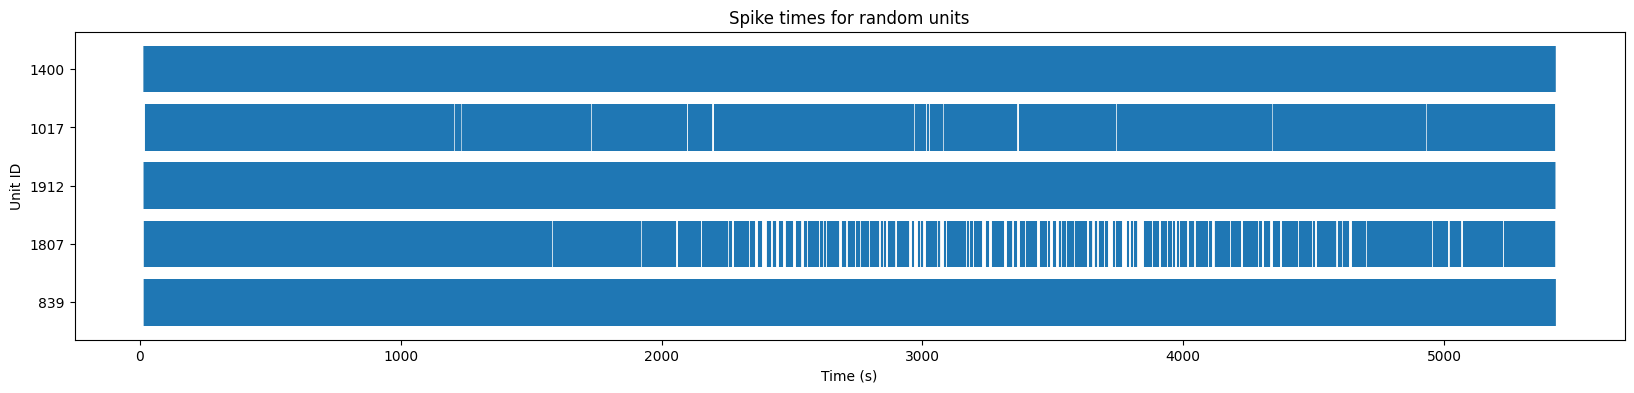

In [11]:
# plot the spike times for these randomly selected units
fig, ax = plt.subplots(figsize=(20, 4))
for row, idx in enumerate(selected_indices):
    # we can grab the spike times for the units using the index of the unit in the NWB file
    spike_times = nwb.units['spike_times'][idx]
    ax.vlines(spike_times, row, row + 0.8)

ax.set_xlabel("Time (s)")
ax.set_yticks(np.arange(n_units_to_plot) + 0.4)
ax.set_yticklabels([str(unit_ids[idx]) for idx in selected_indices])
ax.set_ylabel("Unit ID")
ax.set_title("Spike times for random units")
plt.show()

In [12]:
# uncomment the cell below if you want to plot using plotly
# you can zoom in on the spikes, but it may make the notebook slow to ineract with

In [13]:
# fig = go.Figure()
# for row, idx in enumerate(selected_indices):
#     spike_times = nwb.units['spike_times'][idx]
#     fig.add_trace(go.Scatter(
#         x=spike_times,
#         y=[row] * len(spike_times),
#         mode='markers',
#         marker=dict(symbol='line-ns', size=10, line=dict(width=1, color='black')),
#         name=f"Unit {unit_ids[idx]}",
#         showlegend=False,
#     ))

# fig.update_yaxes(
#     tickmode='array',
#     tickvals=list(range(n_units_to_plot)),
#     ticktext=[str(unit_ids[idx]) for idx in selected_indices],
#     title="Unit ID",
# )
# fig.update_xaxes(title="Time (s)")
# fig.update_layout(height=400, width=900, title="Spike times for random units")
# fig.show()

## As well as plot the individual units responses to stimuli by masking the responses by the stimuli start and stop times

In [14]:
# choose which stimulus table-- it doesn't mattter which!
stim_clean = rf_stim_clean
condition_params = rf_condition_params

# pick a random stimulus by its stimulus_condition_id
random_stimulus_condition_id = np.random.choice(stim_clean['stimulus_condition_id'].unique())
print("Selected stimulus_condition_id:", random_stimulus_condition_id)

# get the rows in the stimulus table that match this stimulus_condition_id
matching_rows = stim_clean[stim_clean['stimulus_condition_id'] == random_stimulus_condition_id]
print(matching_rows[condition_params].iloc[0])
print(f"\nNumber of presentations of this condition: {len(matching_rows)}")

Selected stimulus_condition_id: 0
orientation            0.00
temporal_frequency     4.00
spatial_frequency      0.08
contrast               0.80
x_position           -40.00
y_position           -40.00
Name: 2, dtype: float64

Number of presentations of this condition: 20


In [15]:
# select a single presentation randomly anf get its start time
selected_presentation = matching_rows.sample(1).iloc[0]
single_presentation_time = selected_presentation['start_time']

# we can compute the stimulus duration by subtracting the start time from the stop time
stimulus_duration = selected_presentation['stop_time'] - single_presentation_time
print("Plotting presentation at t =", single_presentation_time, "s, duration =", stimulus_duration, "s")

# we can make a window (before stimulus, after stimulus) to look at the spike times before and after the stimulus presentation too
window = (-0.2, 1.0)  

Plotting presentation at t = 184.88254106036143 s, duration = 0.2502094847818057 s


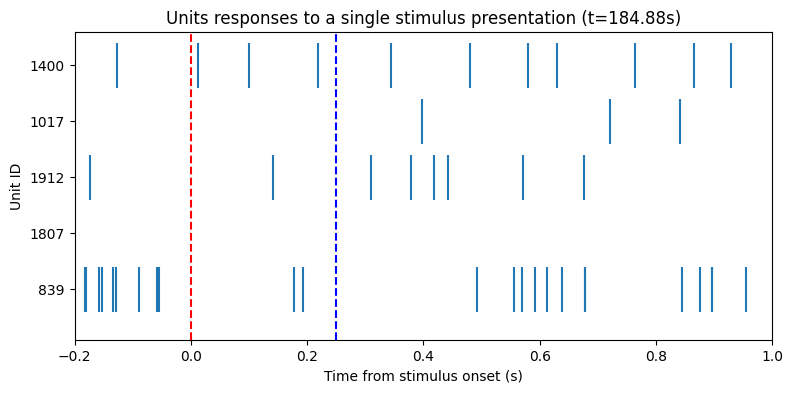

In [16]:
fig, ax = plt.subplots(figsize=(9, 4))
for row, idx in enumerate(selected_indices):
    # we can grab the spike times for the units using the index of the unit in the NWB file
    spike_times = np.asarray(nwb.units['spike_times'][idx])

    # we can mask the spike times to only include those that fall within the window around the stimulus presentation time
    mask = (spike_times >= single_presentation_time + window[0]) & (spike_times <= single_presentation_time + window[1])

    # subtract the single presentation time (start time) from the spike times to center the spike times on 0 
    aligned_spikes = spike_times[mask] - single_presentation_time
    ax.vlines(aligned_spikes, row, row + 0.8)

# plot the stimulus start time-- this will now be 0 because we subtracted the single presentation time from the spike times
ax.axvline(0, color='red', linestyle='--')

# plot the stimulus off time-- this is now just the stimulus duration because we centered the times around 0
ax.axvline(stimulus_duration, color='blue', linestyle='--')
ax.set_xlim(window)
ax.set_ylim(-0.5, n_units_to_plot)
ax.set_xlabel("Time from stimulus onset (s)")
ax.set_yticks(np.arange(n_units_to_plot) + 0.4)
ax.set_yticklabels([str(unit_ids[idx]) for idx in selected_indices])
ax.set_ylabel("Unit ID")
ax.set_title(f"Units responses to a single stimulus presentation (t={single_presentation_time:.2f}s)")
plt.show()

In [17]:
# uncomment the cell below if you want to plot using plotly
# you can zoom in on the spikes, but it may make the notebook slow to ineract with

In [18]:
# fig = go.Figure()
# for row, idx in enumerate(selected_indices):
#     spike_times = np.asarray(nwb.units['spike_times'][idx])
#     mask = (spike_times >= single_presentation_time + window[0]) & (spike_times <= single_presentation_time + window[1])
#     aligned_spikes = spike_times[mask] - single_presentation_time
#     fig.add_trace(go.Scatter(
#         x=aligned_spikes,
#         y=[row] * len(aligned_spikes),
#         mode='markers',
#         marker=dict(symbol='line-ns', size=10, line=dict(width=1, color='black')),
#         showlegend=False,
#     ))

# fig.add_vline(x=0, line=dict(color='red', dash='dash'))
# fig.add_vline(x=stimulus_duration, line=dict(color='blue', dash='dash'))
# fig.update_yaxes(
#     tickmode='array',
#     tickvals=list(range(n_units_to_plot)),
#     ticktext=[str(unit_ids[idx]) for idx in selected_indices],
#     range=[-0.5, n_units_to_plot - 0.5],
#     title="Unit ID",
# )
# fig.update_xaxes(title="Time from stimulus onset (s)", range=list(window))
# fig.update_layout(
#     height=400, width=900,
#     title=f"Unit responses to a single stimulus presentation (t={single_presentation_time:.2f}s)",
# )
# fig.show()

## Remember to close the nwb when you are done!

In [19]:
# this is commented out right now, because it will throw an error if you try to re run intermediate cells without starting from the top 

In [20]:
# io.close()